# Radiation models

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from majordome.common import standard_plot
from majordome.radiation import WSGGRadlibBordbar2020
from matplotlib import pyplot as plt
import numpy as np

## WSGGRadlibBordbar2020

The basic usage of the model to estimate total emissivity is done as follows:

In [3]:
model = WSGGRadlibBordbar2020()
model(L=1, T=1000, P=101325, x_h2o=0.18, x_co2=0.08, fvsoot=0.0)

np.float64(0.18368577452587137)

Evaluation of the model against original source of Bordbar (2014) is satisfactory, as follows:

In [4]:
@standard_plot(shape=(1, 2))
def plot_bordbar2014(_obj, fig, ax):
    """ Reproduce plots of Bordbar (2014), Fig. 2. """
    def scan_flue(T, L, *, M):
        x_co2 = 1 / (1 + M)
        return model(L, T, 101325, M*x_co2, x_co2)

    dry_flue = np.vectorize(lambda T, L: scan_flue(T, L, M=1/8))
    wet_flue = np.vectorize(lambda T, L: scan_flue(T, L, M=1/1))

    L = np.asarray([0.01, 0.1, 0.5, 1.0, 3.0, 5.0, 10.0, 20.0, 60.0])
    T = np.arange(400, 2401, 100)
    sample = np.meshgrid(T, L)

    for n, eps in enumerate(dry_flue(*sample)):
        ax[0].plot(T, eps, label=f"{L[n]} atm.m")

    for n, eps in enumerate(wet_flue(*sample)):
        ax[1].plot(T, eps, label=f"{L[n]} atm.m")

    ax[0].set_title("Dry flue M=1/8")
    ax[1].set_title("Wet flue M=1")

    ax[0].set_xlabel("Temperature [K]")
    ax[1].set_xlabel("Temperature [K]")

    ax[0].set_ylabel("Total emissivity")
    ax[1].set_ylabel("Total emissivity")

    ax[0].set_xlim(400, 2400)
    ax[1].set_xlim(400, 2400)
    ax[0].set_ylim(0, 1)
    ax[1].set_ylim(0, 1)

    ax[0].set_xticks(np.arange(400, 2401, 400))
    ax[1].set_xticks(np.arange(400, 2401, 400))

    ax[0].set_yticks(np.arange(0, 1.01, 0.1))
    ax[1].set_yticks(np.arange(0, 1.01, 0.1))

    ax[0].legend(loc=1, fontsize=9)
    ax[1].legend(loc=1, fontsize=9)

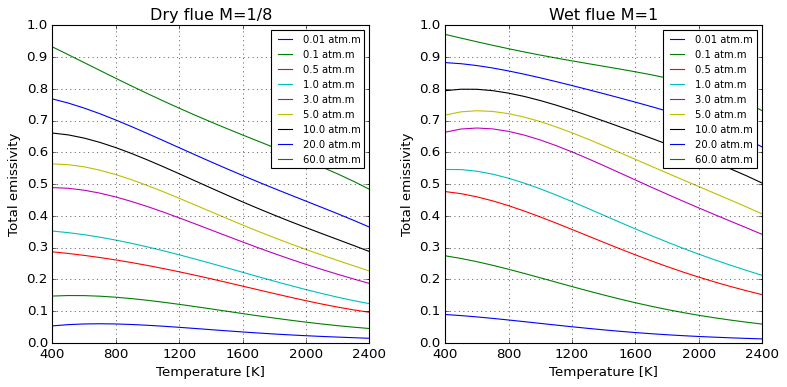

In [5]:
plot_bordbar2014(None).resize(10, 5)

Absorption coefficients for pure substances only reproduce approximately values reported by Bordbar (2020).

In [6]:
model(L=1, T=300, P=101325, x_h2o=0, x_co2=1)
model.absorption_coefs[1:]

array([3.388079e-02, 4.544269e-01, 4.680226e+00, 1.038439e+02])

In [7]:
model(L=1, T=300, P=101325, x_h2o=1, x_co2=0)
model.absorption_coefs[1:]

array([ 0.07703541,  0.8242941 ,  6.854761  , 65.93653   ])